In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [2]:
df = pd.read_csv("../data/churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.dropna(inplace=True)

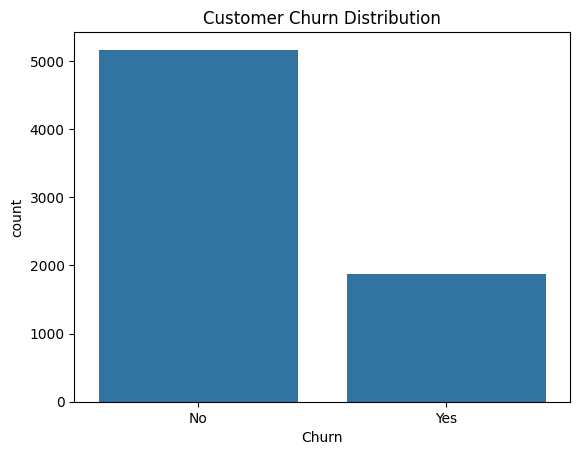

In [8]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

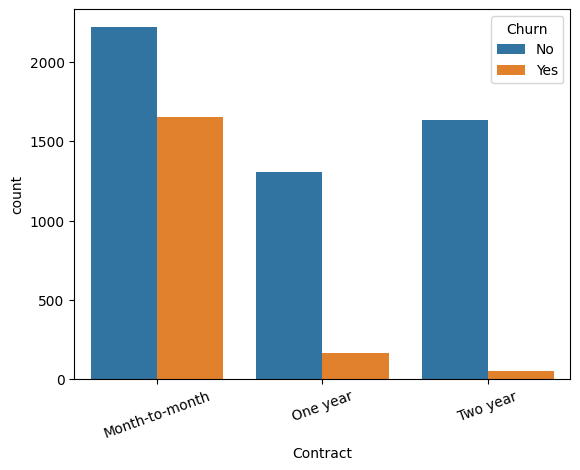

In [9]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.xticks(rotation=20)

plt.show()

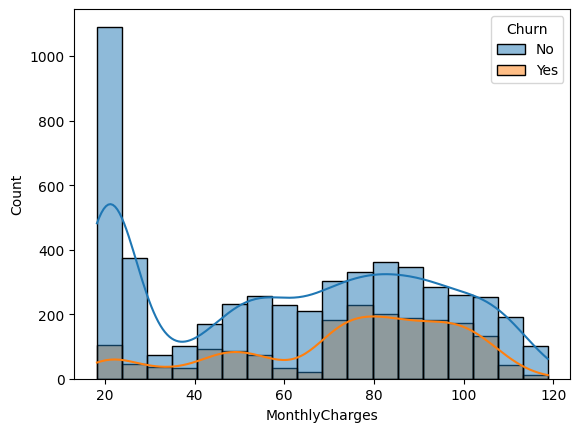

In [10]:
sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    kde=True
)

plt.show()

In [11]:
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

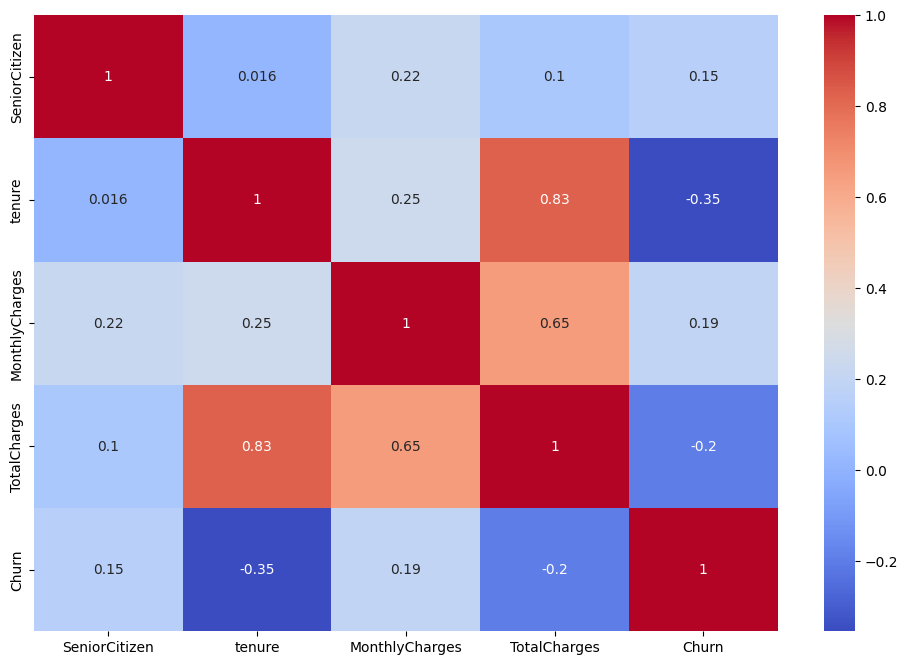

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [13]:
df.drop("customerID", axis=1, inplace=True)

In [14]:
df = pd.get_dummies(
    df,
    columns=["Contract"]
)

In [15]:
X = df[[
    "tenure",
    "MonthlyCharges",
    "Contract_Month-to-month",
    "Contract_One year",
    "Contract_Two year"
]]

feature_names = X.columns

y = df["Churn"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7867803837953091


In [19]:
print(confusion_matrix(y_test, y_pred))

[[933 100]
 [200 174]]


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [21]:
print("ROC-AUC:",
      roc_auc_score(y_test, y_pred))

ROC-AUC: 0.6842176103038241


In [22]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

In [23]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred))

Random Forest Accuracy: 0.7867803837953091


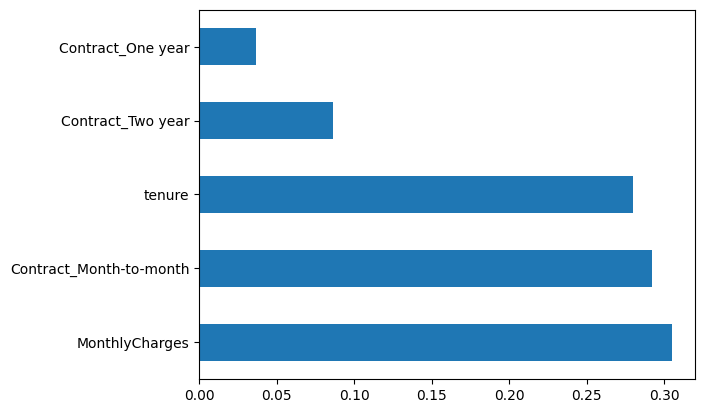

In [24]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.nlargest(10).plot(
    kind="barh"
)

plt.show()

In [25]:
import pickle

In [26]:
pickle.dump(rf, open("../model.pkl", "wb"))

In [27]:
pickle.dump(feature_names,
            open("../features.pkl", "wb"))